# CE49X Midterm Exam - Part 2 (Coding Exercise)
## Power Grid Stability Prediction

**Instructor:** Dr. Eyuphan Koc  
**Department of Civil Engineering, Bogazici University**  
**Date:** April 8, 2026  
**Duration:** 60 minutes  
**Total Points:** 50 (+3 bonus)

---

**Student Name:**  
**Student ID:**

## Background

Electrical grid stability is a critical infrastructure challenge. As cities grow and energy consumption patterns become more complex, maintaining a stable power grid requires understanding how different factors — such as reaction times of energy producers, power consumption patterns, and price sensitivity of consumers — affect overall grid stability.

In this exercise, you will work with the **UCI Electrical Grid Stability** dataset, which contains 10,000 simulated scenarios of a 4-node star power grid. The grid consists of **one energy producer** (node 1) connected to **three consumers** (nodes 2, 3, 4). Each scenario records the operating parameters of all four nodes and whether the grid remained **stable** or became **unstable**.

Your task is to explore the data, identify which factors most influence grid stability, and build a classifier to predict whether a given configuration will be stable or unstable.

> **Key Insight:** This is an infrastructure safety problem. An unstable grid can lead to blackouts, equipment damage, and cascading failures. The cost of failing to detect instability is far greater than the cost of a false alarm.

## Dataset Description

The dataset is from the [UCI Machine Learning Repository](https://archive.ics.uci.edu/dataset/471/) (Dataset #471).

| Feature | Description | Unit |
|---------|-------------|------|
| `tau1` | Reaction time of producer (node 1) | seconds |
| `tau2` | Reaction time of consumer 2 | seconds |
| `tau3` | Reaction time of consumer 3 | seconds |
| `tau4` | Reaction time of consumer 4 | seconds |
| `p1` | Power produced by node 1 | per unit |
| `p2` | Power consumed by node 2 | per unit |
| `p3` | Power consumed by node 3 | per unit |
| `p4` | Power consumed by node 4 | per unit |
| `g1` | Price elasticity coefficient of producer | dimensionless |
| `g2` | Price elasticity coefficient of consumer 2 | dimensionless |
| `g3` | Price elasticity coefficient of consumer 3 | dimensionless |
| `g4` | Price elasticity coefficient of consumer 4 | dimensionless |
| `stab` | Stability measure (continuous) | — |
| **`stabf`** | **Stability label: `stable` or `unstable`** | **— (target)** |

- **Positive `stab`** values indicate instability; negative values indicate stability
- **Power balance:** `p1 + p2 + p3 + p4` should be close to zero (production = consumption)

## Tasks Overview

| # | Task | Points |
|---|------|--------|
| 1 | Data Loading & Exploration | 8 |
| 2 | Feature Engineering | 8 |
| 3 | Grouped Analysis | 10 |
| 4 | Visualization | 12 |
| 5 | Statistical Analysis | 6 |
| 6 | Classification | 6 |
| WQ1 | Written Question 1 | 3 |
| WQ2 | Written Question 2 (Bonus) | 3 |
| **Total** | | **50 (+3 bonus)** |

---
## Your Work Starts Here

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix)
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

---
## Task 1: Data Loading & Exploration (8 pts)

1. Load `data/electrical_grid_stability.csv` into a DataFrame
2. Print the shape and data types
3. Display the first 5 rows
4. Check for missing values
5. Print `.describe()` for all numeric columns
6. Print the value counts of `stabf` (the target variable)

| Criterion | Points |
|---|---|
| Data loaded, shape and dtypes printed | 2 |
| First 5 rows displayed | 1 |
| Missing values checked | 2 |
| `.describe()` printed | 1 |
| `stabf` value counts printed | 2 |

In [5]:
# Load the dataset
df = pd.read_csv("data/electrical_grid_stability.csv")


In [6]:
# Explore: shape, dtypes, head, missing values, describe, value_counts
print("=" * 60)
print("DATASET SHAPE")
print("=" * 60)
print(df.shape)

print("\n" + "=" * 60)
print("DATA TYPES")
print("=" * 60)
print(df.dtypes)

print("\n" + "=" * 60)
print("FIRST 5 ROWS")
print("=" * 60)
display(df.head())

print("\n" + "=" * 60)
print("MISSING VALUES")
print("=" * 60)
print(df.isnull().sum())

print("\n" + "=" * 60)
print("DESCRIPTIVE STATISTICS")
print("=" * 60)
display(df.describe())

print("\n" + "=" * 60)
print("CLASS DISTRIBUTION: stabf")
print("=" * 60)
print(df["stabf"].value_counts())

DATASET SHAPE
(10000, 14)

DATA TYPES
tau1     float64
tau2     float64
tau3     float64
tau4     float64
p1       float64
p2       float64
p3       float64
p4       float64
g1       float64
g2       float64
g3       float64
g4       float64
stab     float64
stabf     object
dtype: object

FIRST 5 ROWS


,tau1,tau2,tau3,tau4,p1,p2,p3,p4,g1,g2,g3,g4,stab,stabf
0,2.959060,3.079885,8.381025,9.780754,3.763085,-0.782604,-1.257395,-1.723086,0.650456,0.859578,0.887445,0.958034,0.055347,unstable
1,9.304097,4.902524,3.047541,1.369357,5.067812,-1.940058,-1.872742,-1.255012,0.413441,0.862414,0.562139,0.781760,-0.005957,stable
2,8.971707,8.848428,3.046479,1.214518,3.405158,-1.207456,-1.277210,-0.920492,0.163041,0.766689,0.839444,0.109853,0.003471,unstable
3,0.716415,7.669600,4.486641,2.340563,3.963791,-1.027473,-1.938944,-0.997374,0.446209,0.976744,0.929381,0.362718,0.028871,unstable
4,3.134112,7.608772,4.943759,9.857573,3.525811,-1.125531,-1.845975,-0.554305,0.797110,0.455450,0.656947,0.820923,0.049860,unstable



MISSING VALUES
tau1     0
tau2     0
tau3     0
tau4     0
p1       0
p2       0
p3       0
p4       0
g1       0
g2       0
g3       0
g4       0
stab     0
stabf    0
dtype: int64

DESCRIPTIVE STATISTICS


,tau1,tau2,tau3,tau4,p1,p2,p3,p4,g1,g2,g3,g4,stab
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,5.250000,5.250001,5.250004,5.249997,3.750000,-1.250000,-1.250000,-1.250000,0.525000,0.525000,0.525000,0.525000,0.015731
std,2.742548,2.742549,2.742549,2.742556,0.752160,0.433035,0.433035,0.433035,0.274256,0.274255,0.274255,0.274255,0.036919
min,0.500793,0.500141,0.500788,0.500473,1.582590,-1.999891,-1.999945,-1.999926,0.050009,0.050053,0.050054,0.050028,-0.080760
25%,2.874892,2.875140,2.875522,2.874950,3.218300,-1.624901,-1.625025,-1.624960,0.287521,0.287552,0.287514,0.287494,-0.015557
50%,5.250004,5.249981,5.249979,5.249734,3.751025,-1.249966,-1.249974,-1.250007,0.525009,0.525003,0.525015,0.525002,0.017142
75%,7.624690,7.624893,7.624948,7.624838,4.282420,-0.874977,-0.875043,-0.875065,0.762435,0.762490,0.762440,0.762433,0.044878
max,9.999469,9.999837,9.999450,9.999443,5.864418,-0.500108,-0.500072,-0.500025,0.999937,0.999944,0.999982,0.999930,0.109403



CLASS DISTRIBUTION: stabf
stabf
unstable    6380
stable      3620
Name: count, dtype: int64


---
## Task 2: Feature Engineering (8 pts)

1. Convert `stabf` to a numeric column called `is_unstable`: 1 if `unstable`, 0 if `stable`
2. Create a new column `total_reaction_time` = `tau1 + tau2 + tau3 + tau4`
3. Create a new column `power_imbalance` = `p1 + p2 + p3 + p4`
4. Create a new column `avg_elasticity` = mean of `g1, g2, g3, g4`
5. Print the class balance: count and percentage of stable vs unstable

| Criterion | Points |
|---|---|
| `is_unstable` created correctly | 2 |
| `total_reaction_time` created | 2 |
| `power_imbalance` created | 1 |
| `avg_elasticity` created | 1 |
| Class balance printed (count + percentage) | 2 |

In [7]:
# Feature engineering
df["is_unstable"] = df["stabf"].map({"stable": 0, "unstable": 1})

df["total_reaction_time"] = df["tau1"] + df["tau2"] + df["tau3"] + df["tau4"]
df["power_imbalance"] = df["p1"] + df["p2"] + df["p3"] + df["p4"]
df["avg_elasticity"] = (df["g1"] + df["g2"] + df["g3"] + df["g4"]) / 4

display(df[[
    "stabf", "is_unstable",
    "total_reaction_time", "power_imbalance", "avg_elasticity"
]].head())

,stabf,is_unstable,total_reaction_time,power_imbalance,avg_elasticity
0,unstable,1,24.200725,-2.886580e-15,0.838878
1,stable,0,18.623519,-6.661338e-16,0.654938
2,unstable,1,22.081132,0.000000e+00,0.469757
3,unstable,1,15.213218,-9.992007e-16,0.678763
4,unstable,1,25.544216,4.996004e-15,0.682607


In [8]:
# Print class balance
class_counts = df["stabf"].value_counts()
class_percentages = df["stabf"].value_counts(normalize=True) * 100

class_balance = pd.DataFrame({
    "count": class_counts,
    "percentage": class_percentages.round(2)
})

print("=" * 60)
print("CLASS BALANCE")
print("=" * 60)
display(class_balance)

CLASS BALANCE


,count,percentage
stabf,,
unstable,6380,63.8
stable,3620,36.2


---
## Task 3: Grouped Analysis (10 pts)

1. Compute the mean of all 12 original features (`tau1`-`tau4`, `p1`-`p4`, `g1`-`g4`) grouped by `stabf`. Which features differ most between stable and unstable grids?
2. Compute the correlation of all 12 original features with `stab` (the continuous stability measure). Identify the **3 features** with the highest absolute correlation.
3. Filter to **unstable grids only**: report the range (min, max) and mean of `tau1` (producer reaction time).
4. Compare `g1` (producer elasticity) statistics between stable and unstable grids — compute mean and std for each group.

| Criterion | Points |
|---|---|
| Grouped means computed and discussed | 3 |
| Top 3 correlated features identified | 3 |
| Unstable grid `tau1` statistics reported | 2 |
| `g1` comparison between groups | 2 |

In [9]:
# Grouped means by stabf
original_features = ["tau1", "tau2", "tau3", "tau4",
                     "p1", "p2", "p3", "p4",
                     "g1", "g2", "g3", "g4"]

grouped_means = df.groupby("stabf")[original_features].mean()

mean_differences = (
    grouped_means.loc["unstable"] - grouped_means.loc["stable"]
).abs().sort_values(ascending=False)

print("=" * 70)
print("MEAN OF ORIGINAL FEATURES GROUPED BY stabf")
print("=" * 70)
display(grouped_means)

print("\n" + "=" * 70)
print("ABSOLUTE DIFFERENCE IN GROUP MEANS (UNSTABLE VS STABLE)")
print("=" * 70)
display(mean_differences.to_frame(name="absolute_mean_difference"))

print("\nFeatures that differ most between stable and unstable grids:")
for feature in mean_differences.head(3).index:
    print(f"- {feature}")

MEAN OF ORIGINAL FEATURES GROUPED BY stabf


,tau1,tau2,tau3,tau4,p1,p2,p3,p4,g1,g2,g3,g4
stabf,,,,,,,,,,,,
stable,4.394799,4.353362,4.385360,4.378495,3.740077,-1.253549,-1.249626,-1.236902,0.453035,0.445872,0.440618,0.450390
unstable,5.735239,5.758752,5.740601,5.744485,3.755630,-1.247987,-1.250212,-1.257431,0.565832,0.569897,0.572879,0.567334



ABSOLUTE DIFFERENCE IN GROUP MEANS (UNSTABLE VS STABLE)


,absolute_mean_difference
tau2,1.405391
tau4,1.365990
tau3,1.355241
tau1,1.340440
g3,0.132261
g2,0.124025
g4,0.116943
g1,0.112797
p4,0.020530
p1,0.015553



Features that differ most between stable and unstable grids:
- tau2
- tau4
- tau3


In [10]:
# Correlation with stab — identify top 3
correlations_with_stab = df[original_features + ["stab"]].corr()["stab"].drop("stab")

top_3_correlated = correlations_with_stab.abs().sort_values(ascending=False).head(3)

print("=" * 70)
print("CORRELATION OF ORIGINAL FEATURES WITH stab")
print("=" * 70)
display(correlations_with_stab.sort_values(key=lambda x: x.abs(), ascending=False).to_frame(name="correlation_with_stab"))

print("\n" + "=" * 70)
print("TOP 3 FEATURES WITH HIGHEST ABSOLUTE CORRELATION WITH stab")
print("=" * 70)

for feature in top_3_correlated.index:
    corr_value = correlations_with_stab[feature]
    print(f"{feature}: {corr_value:.4f}")

CORRELATION OF ORIGINAL FEATURES WITH stab


,correlation_with_stab
g3,0.308235
g2,0.293601
tau2,0.290975
g1,0.282774
tau3,0.280700
g4,0.279214
tau4,0.278576
tau1,0.275761
p4,-0.020786
p1,0.010278



TOP 3 FEATURES WITH HIGHEST ABSOLUTE CORRELATION WITH stab
g3: 0.3082
g2: 0.2936
tau2: 0.2910


In [11]:
# Unstable grids: tau1 range and mean
unstable_tau1_stats = df[df["stabf"] == "unstable"]["tau1"].agg(["min", "max", "mean"])

print("=" * 70)
print("tau1 STATISTICS FOR UNSTABLE GRIDS ONLY")
print("=" * 70)
print(f"Minimum tau1: {unstable_tau1_stats['min']:.4f}")
print(f"Maximum tau1: {unstable_tau1_stats['max']:.4f}")
print(f"Mean tau1:    {unstable_tau1_stats['mean']:.4f}")

tau1 STATISTICS FOR UNSTABLE GRIDS ONLY
Minimum tau1: 0.5013
Maximum tau1: 9.9995
Mean tau1:    5.7352


In [12]:
# Compare g1 between stable and unstable
g1_comparison = df.groupby("stabf")["g1"].agg(["mean", "std"])

print("=" * 70)
print("g1 COMPARISON BETWEEN STABLE AND UNSTABLE GRIDS")
print("=" * 70)
display(g1_comparison)

g1 COMPARISON BETWEEN STABLE AND UNSTABLE GRIDS


,mean,std
stabf,,
stable,0.453035,0.265280
unstable,0.565832,0.270867


---
## Task 4: Visualization (12 pts)

Create **three** publication-quality plots. Each must have axis labels and a descriptive title.

**(a) (4 pts)** A **boxplot** of `tau1` (producer reaction time) grouped by `stabf`. The title should state a finding (not just "Boxplot of tau1").

**(b) (4 pts)** A **scatter plot** of `tau1` (x-axis) vs `g1` (y-axis), colored by `stabf` (use different colors for stable vs unstable). Include a legend.

**(c) (4 pts)** A **correlation heatmap** of all 12 original features (`tau1`-`tau4`, `p1`-`p4`, `g1`-`g4`). Use a sequential or diverging colormap (not rainbow/jet).

| Criterion | Points |
|---|---|
| (a) Boxplot: correct, labeled, finding in title | 4 |
| (b) Scatter: correct, colored by class, legend | 4 |
| (c) Heatmap: correct features, good colormap | 4 |

<Figure size 800x600 with 0 Axes>

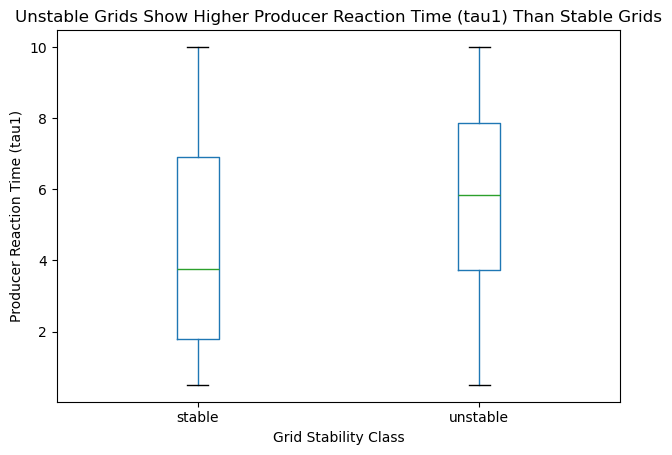

In [13]:
# (a) Boxplot of tau1 by stabf
plt.figure(figsize=(8, 6))

df.boxplot(column="tau1", by="stabf", grid=False)
plt.title("Unstable Grids Show Higher Producer Reaction Time (tau1) Than Stable Grids")
plt.suptitle("")
plt.xlabel("Grid Stability Class")
plt.ylabel("Producer Reaction Time (tau1)")

plt.tight_layout()
plt.show()

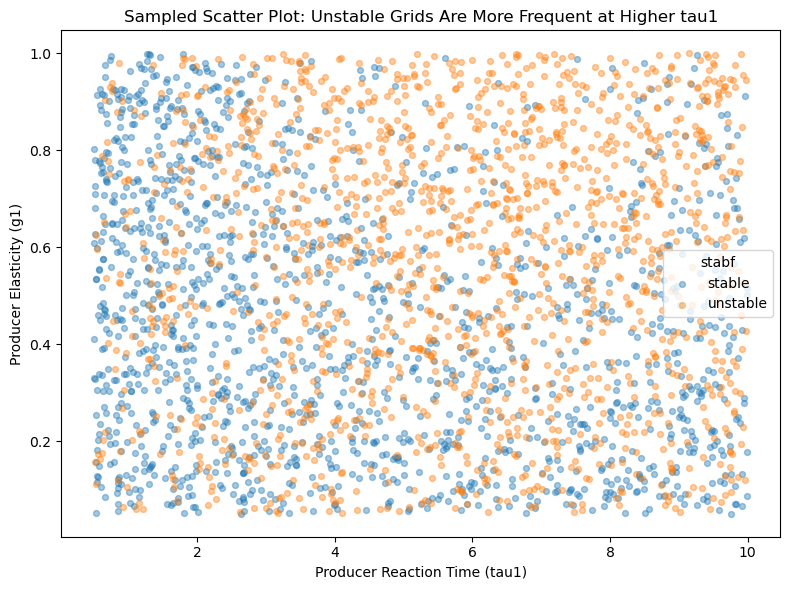

In [17]:
# (b) Scatter plot of tau1 vs g1, colored by stabf
# (b) Scatter plot of tau1 vs g1, colored by stabf
stable_sample = df[df["stabf"] == "stable"].sample(1500, random_state=42)
unstable_sample = df[df["stabf"] == "unstable"].sample(1500, random_state=42)

plt.figure(figsize=(8, 6))

plt.scatter(
    stable_sample["tau1"], stable_sample["g1"],
    s=18, alpha=0.4, label="stable"
)

plt.scatter(
    unstable_sample["tau1"], unstable_sample["g1"],
    s=18, alpha=0.4, label="unstable"
)

plt.title("Sampled Scatter Plot: Unstable Grids Are More Frequent at Higher tau1")
plt.xlabel("Producer Reaction Time (tau1)")
plt.ylabel("Producer Elasticity (g1)")
plt.legend(title="stabf")
plt.tight_layout()
plt.show()

This scatter plot shows the relationship between producer reaction time (tau1), producer elasticity (g1), and grid stability. To improve readability and reduce overplotting, a random sample from each class was plotted instead of using all observations. The plot suggests that unstable cases become more common as tau1 increases, while g1 alone does not create a clear class separation.

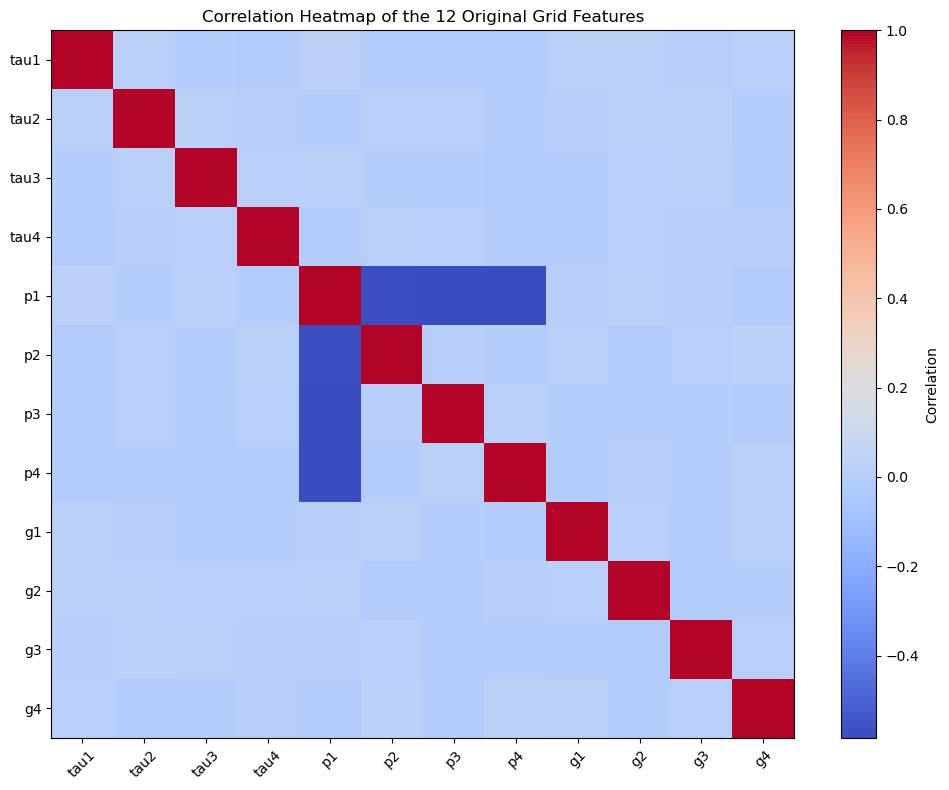

In [15]:
# (c) Correlation heatmap of 12 original features
original_features = ["tau1", "tau2", "tau3", "tau4",
                     "p1", "p2", "p3", "p4",
                     "g1", "g2", "g3", "g4"]

corr_matrix = df[original_features].corr()

plt.figure(figsize=(10, 8))
plt.imshow(corr_matrix, cmap="coolwarm", aspect="auto")
plt.colorbar(label="Correlation")

plt.xticks(range(len(original_features)), original_features, rotation=45)
plt.yticks(range(len(original_features)), original_features)

plt.title("Correlation Heatmap of the 12 Original Grid Features")
plt.tight_layout()
plt.show()

---
## Task 5: Statistical Analysis (6 pts)

1. Compute z-scores for `tau1` across the full dataset. Identify and print samples where |z| > 2 (how many are there?).
2. Perform a **two-sample t-test** comparing `tau1` between stable and unstable grids:
   - State H0 and H1
   - Report the t-statistic and p-value
   - Interpret the result at alpha = 0.05
3. Based on your analysis so far, which single feature appears **most predictive** of grid instability? Justify with numbers.

| Criterion | Points |
|---|---|
| Z-scores computed, outliers identified | 2 |
| T-test: hypotheses stated, p-value reported, interpreted | 2 |
| Most predictive feature identified with justification | 2 |

In [18]:
# Z-scores for tau1
tau1_mean = df["tau1"].mean()
tau1_std = df["tau1"].std(ddof=0)

df["tau1_zscore"] = (df["tau1"] - tau1_mean) / tau1_std

tau1_outliers = df[df["tau1_zscore"].abs() > 2]

print("=" * 70)
print("Z-SCORES FOR tau1")
print("=" * 70)
print(f"Mean of tau1: {tau1_mean:.4f}")
print(f"Standard deviation of tau1: {tau1_std:.4f}")

print("\n" + "=" * 70)
print("SAMPLES WHERE |z| > 2")
print("=" * 70)
print(f"Number of samples with |z| > 2: {len(tau1_outliers)}")

if len(tau1_outliers) > 0:
    display(tau1_outliers[["tau1", "tau1_zscore", "stabf"]].head(10))
else:
    print("No samples with |z| > 2 were found for tau1.")

Z-SCORES FOR tau1
Mean of tau1: 5.2500
Standard deviation of tau1: 2.7424

SAMPLES WHERE |z| > 2
Number of samples with |z| > 2: 0
No samples with |z| > 2 were found for tau1.


In [19]:
# Two-sample t-test: tau1 stable vs unstable
from scipy.stats import ttest_ind

stable_tau1 = df[df["stabf"] == "stable"]["tau1"]
unstable_tau1 = df[df["stabf"] == "unstable"]["tau1"]

t_stat, p_value = ttest_ind(stable_tau1, unstable_tau1, equal_var=False)

print("=" * 70)
print("TWO-SAMPLE T-TEST: tau1 FOR STABLE VS UNSTABLE GRIDS")
print("=" * 70)
print(f"Mean tau1 (stable):   {stable_tau1.mean():.4f}")
print(f"Mean tau1 (unstable): {unstable_tau1.mean():.4f}")
print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.4e}")

TWO-SAMPLE T-TEST: tau1 FOR STABLE VS UNSTABLE GRIDS
Mean tau1 (stable):   4.3948
Mean tau1 (unstable): 5.7352
T-statistic: -23.3033
P-value: 1.3928e-115


### Interpretation

**H0:**  The mean tau1 is the same for stable and unstable grids.
**H1:**  The mean tau1 is different between stable and unstable grids.

**Result:**  The two-sample t-test shows a statistically significant difference in tau1 between stable and unstable grids (t = -23.3033, p < 0.05). Since the p-value is far below 0.05, we reject H0. Unstable grids have a higher mean tau1 than stable grids.

**Most predictive feature:** Based on the correlation analysis, g3 appears to be the most predictive single feature of grid instability because it has the highest absolute correlation with stab (about 0.308). However, tau1 is also an important and interpretable predictor, since unstable grids have a clearly higher mean tau1 and the difference is statistically significant.

---
## Task 6: Classification (6 pts)

1. Define `X` as the 12 original features (`tau1`-`tau4`, `p1`-`p4`, `g1`-`g4`) and `y` as `is_unstable`
2. Split: `train_test_split` with `test_size=0.2`, `random_state=42`, `stratify=y`
3. Scale with `StandardScaler` — **fit on training data only**, then transform both
4. Train `LogisticRegression(max_iter=1000, random_state=42)`
5. Report: accuracy, precision, recall, and F1 for the **unstable** class
6. Print the confusion matrix

| Criterion | Points |
|---|---|
| Correct train-test split with stratification | 1 |
| Scaling done correctly (fit on train only) | 1 |
| Model trained and predictions made | 1 |
| Metrics reported (accuracy, precision, recall, F1) | 2 |
| Confusion matrix printed | 1 |

In [20]:
# Define X and y, split, scale
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

feature_cols = ["tau1", "tau2", "tau3", "tau4",
                "p1", "p2", "p3", "p4",
                "g1", "g2", "g3", "g4"]

X = df[feature_cols]
y = df["is_unstable"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("=" * 70)
print("DATA SPLIT AND SCALING COMPLETED")
print("=" * 70)
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

DATA SPLIT AND SCALING COMPLETED
X_train shape: (8000, 12)
X_test shape: (2000, 12)
y_train shape: (8000,)
y_test shape: (2000,)


In [22]:
# Train, predict, evaluate
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, pos_label=1)
recall = recall_score(y_test, y_pred, pos_label=1)
f1 = f1_score(y_test, y_pred, pos_label=1)
cm = confusion_matrix(y_test, y_pred)

print("=" * 70)
print("LOGISTIC REGRESSION RESULTS")
print("=" * 70)
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision (unstable): {precision:.4f}")
print(f"Recall (unstable):    {recall:.4f}")
print(f"F1-score (unstable):  {f1:.4f}")

print("\n" + "=" * 70)
print("CONFUSION MATRIX")
print("=" * 70)
cm_df = pd.DataFrame(
    cm,
    index=["Actual Stable", "Actual Unstable"],
    columns=["Predicted Stable", "Predicted Unstable"]
)

display(cm_df)

LOGISTIC REGRESSION RESULTS
Accuracy:  0.8200
Precision (unstable): 0.8408
Recall (unstable):    0.8856
F1-score (unstable):  0.8626

CONFUSION MATRIX


,Predicted Stable,Predicted Unstable
Actual Stable,510,214
Actual Unstable,146,1130


---
## Written Questions

### Written Question 1 (3 pts)

Look at your confusion matrix from Task 6. In the context of **power grid management**, which error is more dangerous:

- **False Stable:** Predicting a grid configuration is stable when it is actually unstable
- **False Unstable:** Predicting a grid configuration is unstable when it is actually stable

Explain in 2-3 sentences. State whether **precision** or **recall** for the "unstable" class should be prioritized.

---

*Your answer here...*

False stable is the more dangerous error because it means the model fails to identify a truly unstable grid configuration. In a real power grid, this could delay corrective action and increase the risk of cascading failures or service disruption. For this reason, recall for the “unstable” class should be prioritized over precision, since missing an unstable case is more costly than issuing a false warning.

### Written Question 2 — BONUS (3 pts)

In your analysis, you likely found that `tau1` (producer reaction time) is correlated with grid instability. Does this prove that slow producer reaction times **cause** instability?

Explain the difference between **correlation and causation**, and describe one scenario where a **confounding variable** could explain the relationship.

---

*Your answer here...*

No, correlation does not prove causation. Although tau1 is clearly associated with instability in this dataset, that does not mean slow producer reaction time by itself directly causes instability. For example, a confounding variable such as higher producer elasticity (g1) or a more stressed operating condition could increase both tau1 and the likelihood of instability, creating a correlation even if the true mechanism is more complex.

---

### End of Part 2

**Dr. Eyuphan Koc**  
eyuphan.koc@bogazici.edu.tr